## Generative Adversarial Networks (GANs)

План на сегодня: реализуем генерацию лиц с обучением генеративной состязательной сети (GAN)

Для самостоятельных упражнений вы можете выбрать любой из датасетов:
- CelebA: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
- PeopleArt: https://www.kaggle.com/datasets/amanagr/people-art-dataset
- Best Artworks of All Time: https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time
- Cartoon Faces (Google's Cartoon Set): https://www.kaggle.com/datasets/brendanartley/cartoon-faces-googles-cartoon-set

### Подготовим данные

#### Задание 1 (2 балла). Завершите реализацию GAN

Реализуйте методы `generator_step` и `discriminator_step` в классе `GAN` с последней [практики](../workshops/12_gan.ipynb)

#### Задание 2 (4 баллов). Базовое обучение

Запустите обучение модели
- минимальное кол-во шагов: 50000 (например 50 эпох по 1000 батчей в каждой)
- минимальный размер батча: 32 (можете увеличить, если не наблюдаете при этом кратной просадки по скорости)
- в конце обучения сгенерируйте 64 изображения

#### Задание 3 (3+5 баллов). Более стабильные версии GAN

Модифицируйте вычисление ошибки для более стабильного обучения.
- (3 балла) LSGAN (https://paperswithcode.com/method/lsgan)
- (5 балла) Wasserstein GAN + Gradient penalty (https://paperswithcode.com/method/wgan-gp)

Запустите обучение той же длительности, что в задании 2 (>50000 шагов, батч > 32) и сгенерируйте 64 изображения. Сравните результаты с заданием 2

In [1]:
%pip install lightning

from pathlib import Path
from typing import Callable, cast

import lightning as L
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision
from lightning.pytorch.loggers import TensorBoardLogger
from PIL import Image
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip


/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/local/lib/python3.10/dist-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
class ImageDataset(Dataset):
    def __init__(
        self,
        datadir: Path,
        transform: Callable[[Image.Image], Tensor],
        pattern: str = "*.jpg",
    ) -> None:
        self.images = list(datadir.rglob(pattern))
        self.transform = transform

    def __getitem__(self, index) -> Tensor:
        img = Image.open(self.images[index])
        return self.transform(img)

    def __len__(self) -> int:
        return len(self.images)

In [3]:
transform = transforms.Compose(
    [
        transforms.Resize(64),
        transforms.CenterCrop(64),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

In [4]:
# !curl -L -o celeba-dataset.zip https://www.kaggle.com/api/v1/datasets/download/jessicali9530/celeba-dataset

In [5]:
# !unzip -qq -n celeba-dataset.zip -d celeba/

In [6]:
# если работаете локально или в Google Colab, укажите правильный путь до папки с изображениями
datadir = Path("./celeba/img_align_celeba")
dataset = ImageDataset(
    datadir,
    transform=transform,
)
print(len(dataset))
print(dataset[0].shape)

202599
torch.Size([3, 64, 64])


In [7]:
loader = DataLoader(dataset, batch_size=16, shuffle=True)

batch = next(iter(loader))
print(batch.shape)

torch.Size([16, 3, 64, 64])


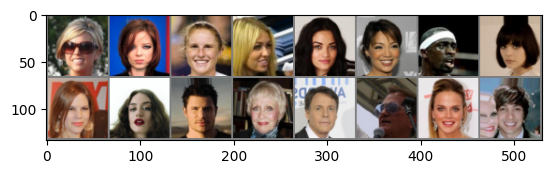

In [8]:
img_grid = torchvision.utils.make_grid(
    tensor=batch,
    nrow=8,
    padding=2,
    normalize=False,
)

plt.imshow(
    torchvision.transforms.ToPILImage()(
        img_grid * torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
        + torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    )
)

### Обучение GAN

Генеративная состязательная сеть — не одна модель, а скорее парадигма обучения, в которой используются две модели:
1. Генератор: генерирует новые примеры данных, пытаясь обмануть дискриминатор
2. Дискриминатор: классифицирует наблюдения на реальные и созданные генератором

Ошибка дискриминатора: $E_{x \sim p_{data}(x)}[\log D(x)] + E_{x \sim p_{g}(x)}[\log (1 - D(x))]$

<img src="https://developers.google.com/static/machine-learning/gan/images/gan_diagram_discriminator.svg" style="background:white" width="700"/>

Ошибка генератора: $- E_{z \sim p_z(z)}[\log D(G(z))]$

<img src="https://developers.google.com/static/machine-learning/gan/images/gan_diagram_generator.svg" style="background:white" width="700"/>

Обучение GAN — то ещё приключение, есть несколько трюков, которые более-менее работают: https://github.com/soumith/ganhacks

In [9]:
import torch
import torch.nn.functional as F
import typing

class GANLoss:
    def __init__(self, gan_type: str | None = None):
        self.gan_type = gan_type

    def generator_loss(self, fake_scores: torch.Tensor) -> torch.Tensor:
        if self.gan_type == "lsgan":
            return F.mse_loss(fake_scores, torch.ones_like(fake_scores))

        if self.gan_type == "wgan":
            return -fake_scores.mean()

        return F.binary_cross_entropy_with_logits(fake_scores, torch.ones_like(fake_scores))

    def discriminator_loss(
        self,
        real_scores: torch.Tensor,
        fake_scores: torch.Tensor
    ) -> torch.Tensor:
        if self.gan_type == "lsgan":
            real_loss = F.mse_loss(real_scores, torch.ones_like(real_scores))
            fake_loss = F.mse_loss(fake_scores, torch.zeros_like(fake_scores))
            return 0.5 * (real_loss + fake_loss)

        if self.gan_type == "wgan":
            return fake_scores.mean() - real_scores.mean()

        real_loss = F.binary_cross_entropy_with_logits(real_scores, torch.ones_like(real_scores))
        fake_loss = F.binary_cross_entropy_with_logits(fake_scores, torch.zeros_like(fake_scores))
        return 0.5 * (real_loss + fake_loss)

class GAN(L.LightningModule):
    def __init__(
        self,
        generator: nn.Module,
        discriminator: nn.Module,
        discriminator_period: int = 5,
        gan_type: str | None = None,
    ):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.discriminator_period = discriminator_period
        self.loss = GANLoss(gan_type)

        # NB: у нас 2 оптимизатора, поэтому обновлять параметры будем вручную
        self.automatic_optimization = False

    def generate(self, n: int) -> Tensor:
        # Генерируем n изображений из случайного шума
        device = next(self.generator.parameters()).device
        latent_size, *_ = next(self.generator.parameters()).data.shape
        z = torch.randn(n, latent_size, 1, 1, device=device)
        return self.generator(z)

    def training_step(self, batch: Tensor, batch_idx: int) -> None:
        # Шаг генератора
        self.generator_step(batch)

        # Шаг дискриминатора
        if batch_idx % self.discriminator_period == 0:
            self.discriminator_step(batch)

    def configure_optimizers(self):
        # наши 2 оптимизатора: один для параметров генератора, другой — для параметров дискриминатора
        gen_opt = torch.optim.Adam(
            self.generator.parameters(), lr=0.0002, betas=(0.5, 0.999)
        )
        dis_opt = torch.optim.Adam(
            self.discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999)
        )
        return [gen_opt, dis_opt]

    def generator_step(self, batch: Tensor) -> None:
        optimizer_g, _ = self.optimizers(use_pl_optimizer=True)

        # Отключаем расчёт градиентов для параметров, которые не относятся к `optimizer_g`
        self.toggle_optimizer(optimizer_g)

        # Генерируем батч изображений
        z = torch.randn(batch.size(0), self.generator.latent_size, 1, 1, device=self.device)
        fake = self.generator(z)

        # Получаем оценку дискриминатора для `fake`
        fake_scores = self.discriminator(fake)
        # Считаем ошибку генератора (цель генератора - обмануть дискриминатор, поэтому метки "1")
        g_loss = self.loss.generator_loss(fake_scores)

        # Обновляем параметры генератора
        self.manual_backward(g_loss)
        optimizer_g.step()
        optimizer_g.zero_grad()

        # Восстанавливаем состояние параметров (обратное действие к `toggle_optimizer`)
        self.untoggle_optimizer(optimizer_g)

        self.log("g_loss", g_loss, prog_bar=True)

    def discriminator_step(self, batch: Tensor) -> None:
        _, optimizer_d = self.optimizers(use_pl_optimizer=True)

        # Отключаем расчёт градиентов для параметров, которые не относятся к `optimizer_d`
        self.toggle_optimizer(optimizer_d)

        # Считаем ошибку дискриминатора на реальных изображениях (метки "1")
        real_scores = self.discriminator(batch)
        # Считаем ошибку дискриминатора на сгенерированных изображениях (метки "0")
        z = torch.randn(batch.size(0), self.generator.latent_size, 1, 1, device=self.device)
        fake = self.generator(z)
        # Отключаем градиенты по генератору при обучении дискриминатора
        fake_scores = self.discriminator(fake.detach())

        # Обновляем параметры дискриминатора
        d_loss = self.loss.discriminator_loss(real_scores, fake_scores)

        self.manual_backward(d_loss)
        optimizer_d.step()
        optimizer_d.zero_grad()

        # восстанавливаем состояние параметров (обратное действие к `toggle_optimizer`)
        self.untoggle_optimizer(optimizer_d)

        self.log("d_loss", d_loss, prog_bar=True)

    def on_train_epoch_end(self) -> None:
        images = self.generate(16)
        grid = torchvision.utils.make_grid(
            tensor=images,
            nrow=8,
            padding=2,
            normalize=True,
            value_range=(-1, 1),
        )
        str_title = f"{self.__class__.__name__}_images"
        logger = cast(TensorBoardLogger, self.logger)
        logger.experiment.add_image(str_title, grid, global_step=self.global_step)


#### Простые архитектуры генератора и дискриминатора

In [10]:
class Generator(nn.Module):
    def __init__(self, latent_size: int):
        super().__init__()
        self.latent_size = latent_size

        self.conv1 = nn.ConvTranspose2d(latent_size, 64 * 8, 4, 1, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(64 * 8)
        self.conv2 = nn.ConvTranspose2d(64 * 8, 64 * 4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(64 * 4)
        self.conv3 = nn.ConvTranspose2d(64 * 4, 64 * 2, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64 * 2)
        self.conv4 = nn.ConvTranspose2d(64 * 2, 64, 4, 2, 1, bias=False)
        self.bn4 = nn.BatchNorm2d(64)

        self.conv5 = nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)
        x = F.relu(self.bn3(self.conv3(x)), inplace=True)
        x = F.relu(self.bn4(self.conv4(x)), inplace=True)
        return torch.tanh(self.conv5(x))


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, 4, 2, 1, bias=False)
        self.conv2 = nn.Conv2d(64, 64 * 2, 4, 2, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64 * 2)
        self.conv3 = nn.Conv2d(64 * 2, 64 * 4, 4, 2, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(64 * 4)
        self.conv4 = nn.Conv2d(64 * 4, 64 * 8, 4, 2, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(64 * 8)
        self.conv5 = nn.Conv2d(64 * 8, 1, 4, 1, 0, bias=False)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn1(self.conv2(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn2(self.conv3(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.bn3(self.conv4(x)), negative_slope=0.2, inplace=True)
        x = self.conv5(x).view(-1, 1)
        return x

In [12]:
# %pip install tensorrt

import torch.multiprocessing as mp

# mp.set_start_method('spawn', force=True)
# mp.set_start_method('subprocess')

torch.set_float32_matmul_precision('medium')

# if __name__ == '__main__':
    # torch.multiprocessing.set_start_method('fork', force=True)

generator = Generator(latent_size=256)
discriminator = Discriminator()

max_epochs=50
limit_train_batches=1000

def run_gan(gan_type: str | None = None, max_epochs=max_epochs, limit_train_batches=limit_train_batches):
    logger = TensorBoardLogger(save_dir="logs", name="gan")
    trainer = L.Trainer(
        max_epochs=max_epochs,
        logger=logger,
        limit_train_batches=limit_train_batches,
        # devices=2,
    )

    lit = GAN(generator, discriminator, discriminator_period=3)
    loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=28)

    trainer.fit(model=lit, train_dataloaders=loader)

    model_version = f"version_{logger.version}"
    checkpoint_path = next(Path(f"logs/gan/{model_version}/checkpoints/").glob("*.ckpt"))
    lit = GAN(generator, discriminator, discriminator_period=3)
    lit.load_state_dict(torch.load(checkpoint_path, weights_only=True)["state_dict"])
    images = lit.generate(n=64)
    grid = torchvision.utils.make_grid(
        tensor=images,
        nrow=8,
        padding=2,
        normalize=True,
        value_range=(-1, 1),
    )
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(torchvision.transforms.ToPILImage()(grid))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | discriminator | Discriminator | 2.8 M  | train
1 | generator     | Generator     | 4.9 M  | train
--------------------------------------------------------
7.6 M     Trainable params
0         Non-trainable params
7.6 M     Total params
30.481    Total estimated model params size (MB)
19        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 1000/1000 [00:12<00:00, 77.15it/s, v_num=1, g_loss=2.070, d_loss=0.254]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 1000/1000 [00:13<00:00, 72.04it/s, v_num=1, g_loss=2.070, d_loss=0.254]


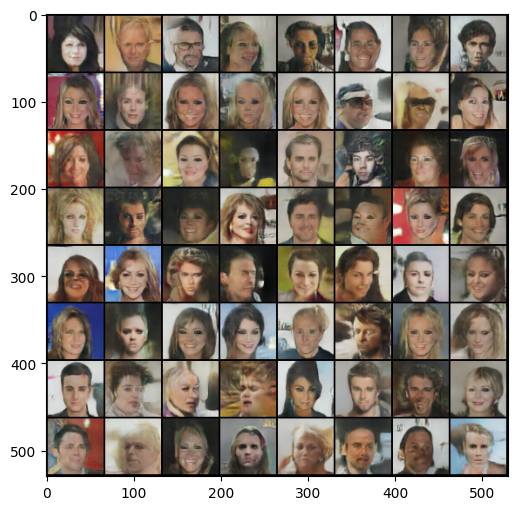

In [13]:
run_gan(None)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | discriminator | Discriminator | 2.8 M  | train
1 | generator     | Generator     | 4.9 M  | train
--------------------------------------------------------
7.6 M     Trainable params
0         Non-trainable params
7.6 M     Total params
30.481    Total estimated model params size (MB)
19        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 1000/1000 [00:12<00:00, 79.10it/s, v_num=2, g_loss=1.200, d_loss=0.460] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 1000/1000 [00:13<00:00, 74.94it/s, v_num=2, g_loss=1.200, d_loss=0.460]


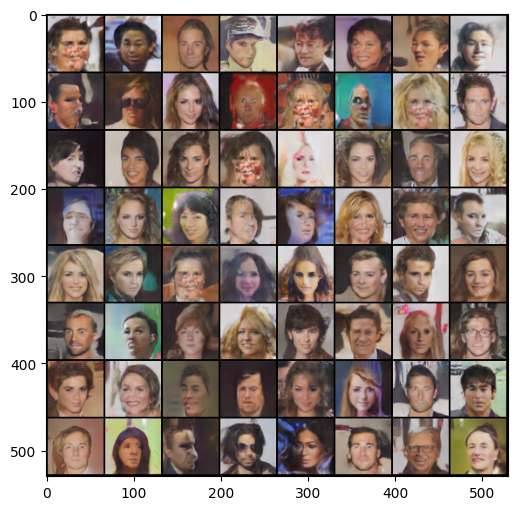

In [14]:
run_gan('lsgan')

Подгружаем лучшие веса и наслаждаемся:

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | discriminator | Discriminator | 2.8 M  | train
1 | generator     | Generator     | 4.9 M  | train
--------------------------------------------------------
7.6 M     Trainable params
0         Non-trainable params
7.6 M     Total params
30.481    Total estimated model params size (MB)
19        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 1000/1000 [00:12<00:00, 78.00it/s, v_num=3, g_loss=3.430, d_loss=0.0784]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 1000/1000 [00:13<00:00, 71.51it/s, v_num=3, g_loss=3.430, d_loss=0.0784]


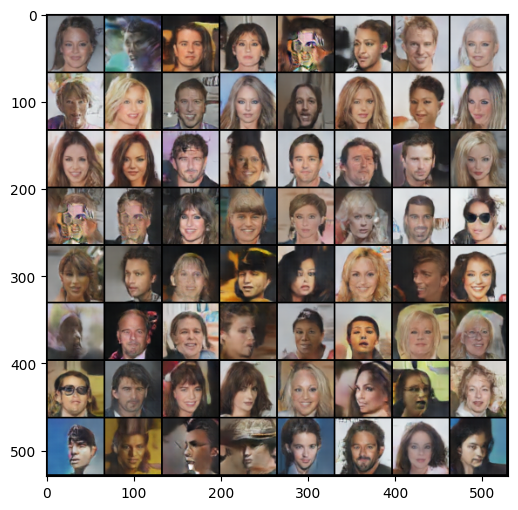

In [15]:
run_gan('wgan')

### Упражнения

1. Реализуйте обучение LSGAN (https://paperswithcode.com/method/lsgan)
2. Реализуйте обучение Wasserstein GAN + Gradient penalty (https://paperswithcode.com/method/wgan-gp)